# Dev / test notebook for data labels and loading for DEAR

Need to make sure things are ok:
- interactive annotation + rush mean there's already issues I've found
- amending DEAR's data loading to be less 'research-grade' but need to make sure not breaking things in the process


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import logging
import torch 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

sys.path.append('..')

import src.data_utils as dut
import src.plotting as splo

import src.dear.utils as sdu
import src.dear.data as sdd

## Set up namespace, e.g. point to data

In [9]:
config_dict = {
    'data_root' : '../data/',
    'dataset' : 'xView_0',
    'label_file': 'labels.csv',
    'batch_size' : 15,
    'normalize': False,
    'add_flips': False,
    'label_idx': ['buildings','roads','cars'],
    'image_size': 64,
    'sup_prop': 1,
}
args = sdu.DummyArgs( config_dict)
args.data_dir = f'{args.data_root}{args.dataset}'

In [28]:
def image_x_y_from_str( str_):
    x_ = str_.split('x')[1].split('_')[0].split('.')[0]
    y_ = str_.split('y')[1].split('_')[0].split('.')[0]
    im_ = str_.split('tif')[1].split('_')[0]
    return im_, x_, y_

def plot_batch_of_3xN( x, labels, names, N= 5):
    f, axs = plt.subplots( ncols= 3, nrows= N, figsize= (9,3*N),)
    axs = axs.reshape(-1)
    for ii, im in enumerate( x):
        im_ar = dut.to_numpy( im)
        min_, max_ = int(im_ar.min()), int(im_ar.max())
        axs[ii].imshow( im_ar)
        axs[ii].get_xaxis().set_visible(False)
        axs[ii].get_yaxis().set_visible(False)
        b_, r_, c_ = [int(x) for x in labels[ ii].numpy()]
        if b_!=-1:
            title = f'b{b_} r{r_} c{c_}, {min_}-{max_}'
        else:
            title = f'         , {min_}-{max_}'
        im_,x_,y_ = image_x_y_from_str( names[ ii])
        title += f'\ntif{im_}_x{x_}_y{y_}'
        axs[ii].set_title( title, fontsize= 10)
    return f

def filt_( dataset, name_f, label_f):
    """filter a dataset object - DEAR dataset specifically - based on callable conditions to be applied
    to name of sample and labels of sample, return index of sample"""
    return [
        ii for ii, (n, l) in enumerate( zip( dataset.image_names, dataset.labels)) if name_f( n) and label_f( l)
    ]

### check out data loader etc

In [10]:
data_loader, _ = sdd.make_dataloader( args)

Loaded labels from ../data/xView_0\labels.csv, total of 8172 entries.
First entry: tif102_x65_y1613.png, with labels [-1. -1. -1.]


In [ ]:
x, labels, names = sdd.get_batch_no( data_loader, 0)
if args.normalize:
    x = [sdu.denorm( im) for im in x]
x.shape, labels.shape

In [ ]:
#_ = plot_batch_of_3xN( x, labels, names)

Below cell allows to output the images in batches of 15, labelled, for visual inspection / sanity checks. Takes a while, may be better to output random ones only (needed to understand better what was going wrong in first xView attempt)

In [10]:
out_dir = f'{args.data_dir}sanity_checks/'
os.makedirs( out_dir, exist_ok= True)

for batch_idx, (x, labels, names) in enumerate( data_loader):
    if args.normalize:
        x = [sdu.denorm( im) for im in x]
    f = plot_batch_of_15( x, labels, names)
    f.savefig(f'{out_dir}batch_{batch_idx}.png', dpi= 300, bbox_inches= 'tight')
    plt.close()

Next cells are for comparing original (broken) dataset and the new fixed one

In [14]:
im_to_check = 'tif109_x296_y1534.png'

In [13]:
dataset_0 = sdd.DatasetLabelled( args.data_dir, 128, args.label_file, args.label_idx, normalize= False)
dataset_1 = sdd.DatasetLabelled( f'{args.data_dir}_fix', 128, args.label_file, args.label_idx, normalize= False)

Loaded labels from ../data/xView_0\labels.csv, total of 8172 entries.
First entry: tif102_x65_y1613.png, with labels [-1. -1. -1.]
Loaded labels from ../data/xView_0_fix\labels.csv, total of 8154 entries.
First entry: tif102_x65_y1613.png, with labels [-1 -1 -1]


In [15]:
ii_0 = [ii for ii, x in enumerate(dataset_0.image_names) if x==im_to_check][0]
[ii for ii, x in enumerate(dataset_1.image_names) if x==im_to_check]

[]

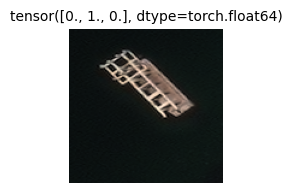

In [18]:
im_0, l_0, _ = dataset_0.__getitem__( ii_0)
ax = splo.plot_single( dut.to_numpy( im_0), figsize= (2,2))
_ = ax.set_title( str(l_0), fontsize= 10)

In [19]:

name_cond = lambda x: x.startswith('tif109')
label_cond = lambda x: x[1]!=-1

In [20]:
check0 = filt_( dataset_0, name_cond, label_cond)
check1 = filt_( dataset_1, name_cond, label_cond)

In [32]:
st_ = 1

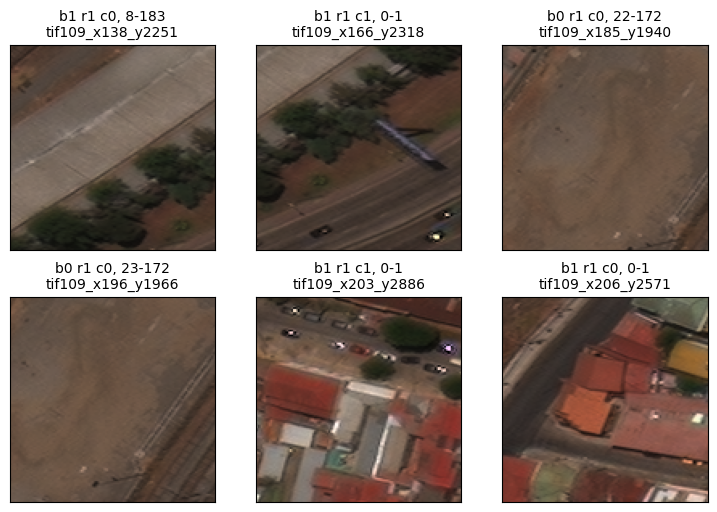

In [33]:
batch0, x0, l0, n0 = [], [], [], []
st = st_*6
_ = [batch0.append( dataset_0.__getitem__( check0[x])) for x in range(st,st+6)]
_ = [(x0.append(x_), l0.append(l_), n0.append(n_)) for x_, l_, n_ in batch0]
_ = plot_batch_of_3xN( x0, l0, n0, N= 2)

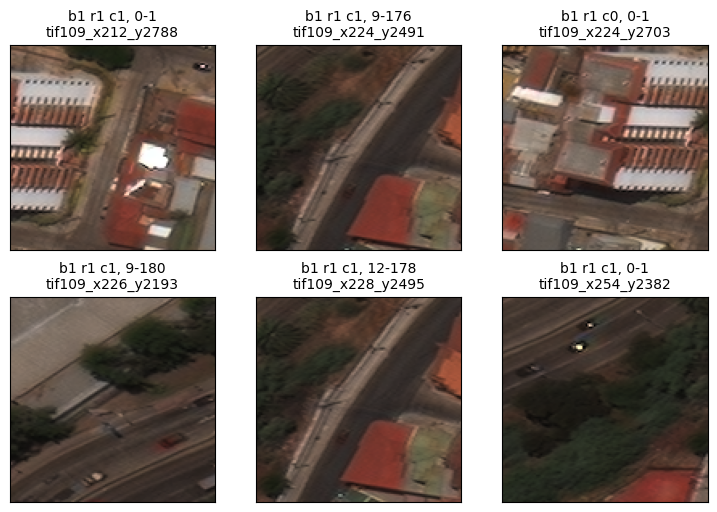

In [34]:
batch1, x1, l1, n1 = [], [], [], []
st = st_*6
_ = [batch1.append( dataset_1.__getitem__( check1[ x])) for x in range(st,st+6)]
_ = [(x1.append(x_), l1.append(l_), n1.append(n_)) for x_, l_, n_ in batch1]
_ = plot_batch_of_3xN( x1, l1, n1, N=2)

In [31]:
[all(l0[i]==l1[i]) for i in range(len(l0))]

[False, False, False, False, False, False]